# CIFAR-10 AlexNet (Jupyter Notebook)

## Overview
This notebook demonstrates how to set up an AlexNet-inspired convolutional neural network for the CIFAR-10 image classification dataset. It focuses on installing dependencies, loading data, preprocessing, and defining the model architecture.

## Dataset Summary
- **CIFAR-10** consists of 60,000 color images sized 32×32.
- **Classes:** 10 categories (e.g., airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).
- **Split:** 50,000 training images and 10,000 test images.

## Environment Setup
The first cell installs required libraries:
- TensorFlow/Keras for model building.
- NumPy for numerical operations.
- Matplotlib for potential visualization.

## Data Loading
The CIFAR-10 dataset is loaded using `tensorflow.keras.datasets.cifar10`.  
It returns:
- `x_train`, `y_train` for training.
- `x_test`, `y_test` for testing.

## Data Preprocessing
- Pixel values are normalized to the range `[0, 1]` by dividing by 255.
- Labels are one-hot encoded to match the 10 output classes.

## Model Architecture (AlexNet-style)
The model is built using Keras Sequential API and includes:
- Multiple **convolutional layers** with ReLU activations.
- **Batch normalization** for stable training.
- **Max pooling** to reduce spatial dimensions.
- **Flatten** to transition to dense layers.
- Two large **fully connected layers** with dropout for regularization.
- A final **softmax output layer** for multi-class classification.

## Output
The model summary is printed to verify the layer stack and parameter counts.

## Next Steps (Optional)
- Compile the model with an optimizer and loss function.
- Train using `model.fit()` and evaluate with `model.evaluate()`.
- Visualize training metrics and sample predictions.

## Notes
This notebook is structured for clarity and quick iteration; training is not included by default.


In [ ]:
%pip install tensorflow
%pip install keras
%pip install matplotlib
%pip install numpy
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

e:\MCA\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
print(x_train.shape)
print(y_train.shape)  
print(x_test.shape)   
print(y_test.shape)   

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [4]:
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
# convert class vectors to binary class metrices
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
# Define AlexNet Model in keras
input_shape = (32, 32, 3)
num_classes = 10
alexnet = models.Sequential()

# Layer 1: Conv Layer
alexnet.add(Conv2D(96,(11,11), strides = 4, padding = 'same', input_shape = input_shape))
alexnet.add(layers.BatchNormalization())
alexnet.add(layers.Activation('relu'))
alexnet.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))

# Layer 2: Conv Layer
alexnet.add(Conv2D(256, (5, 5), padding = 'same'))
alexnet.add(layers.BatchNormalization())
alexnet.add(layers.Activation('relu'))
alexnet.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))

# Layer 3: Conv Layer
alexnet.add(Conv2D(384, (3, 3), padding = 'same'))

# Layer 4: Conv Layer
alexnet.add(Conv2D(384, (3, 3), padding = 'same'))

# Layer 5: Conv Layer
alexnet.add(Conv2D(256, (3, 3), padding = 'same'))
alexnet.add(layers.Activation('relu'))
alexnet.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))

# Flatten the data for the fully connected layers
alexnet.add(Flatten())

# Layer 6: Fully Connected Layer
alexnet.add(Dense(4096))
alexnet.add(layers.Activation('relu'))
alexnet.add(layers.Dropout(0.5))

# Layer 7: Fully Connected Layer
alexnet.add(Dense(4096))
alexnet.add(layers.Activation('relu'))
alexnet.add(layers.Dropout(0.5))

# Layer 8: Output Layer
alexnet.add(Dense(num_classes))
alexnet.add(layers.Activation('softmax'))

e:\MCA\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compile the model
alexnet.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
alexnet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 96)       │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,789,386 (178.49 MB)

 Trainable params: 46,788,682 (178.48 MB)

 Non-trainable params: 704 (2.75 KB)

In [9]:
tf.keras.utils.plot_model(alexnet, to_file='alexnet_model.png', show_shapes=True, show_layer_names=True, show_dtype=False)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [10]:
# Create data augmentation generator
datagen = ImageDataGenerator(
    width_shift_range=0.1,  # randomly shift images horizontally (10% of total width)
    height_shift_range=0.1, # randomly shift images vertically (10% of total height)
    horizontal_flip=True,   # randomly flip images horizontally
)

In [11]:
datagen.fit(x_train)

In [12]:
# Train the model
history = alexnet.fit(datagen.flow(x_train, y_train, batch_size=512), epochs=2, validation_data=(x_test, y_test), verbose=1)

Epoch 1/2
98/98 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.0972 - loss: 364246.3438 - val_accuracy: 0.1000 - val_loss: 2.3048
Epoch 2/2
98/98 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.0999 - loss: 2.9247 - val_accuracy: 0.1000 - val_loss: 2.3028


In [13]:
test_loss, test_acc = alexnet.evaluate(x_test, y_test, verbose = 2)
print('Test accuracy:', test_acc)

313/313 - 11s - 36ms/step - accuracy: 0.1000 - loss: 2.3028
Test accuracy: 0.10000000149011612


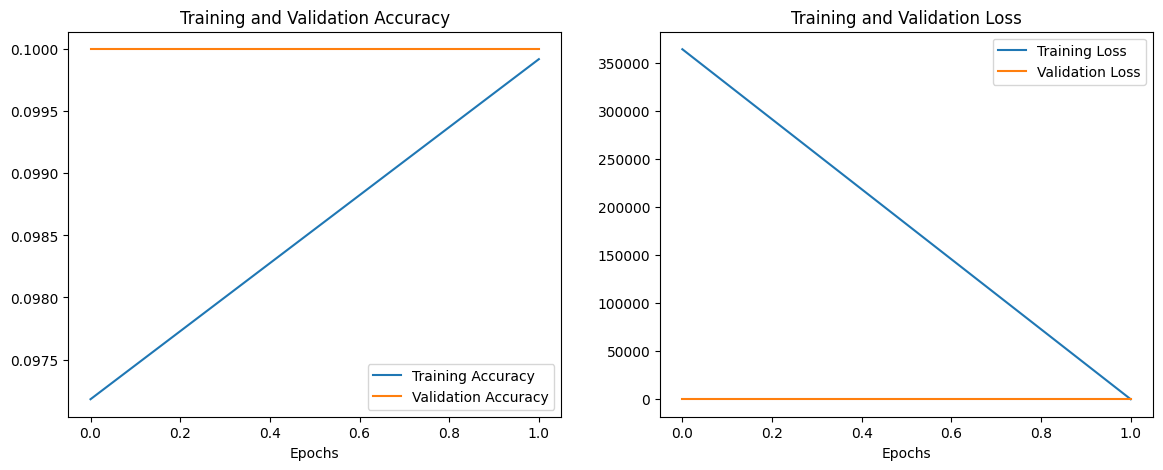

In [14]:
# plotting the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.legend(loc = 'lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()